**Lab 6: IIR Filtering**


The objective for this lab is to help you understand the relationship between the location
of poles and zeros in the z-domain, the impulse response h[n] in the n-domain, and the frequency
response $H(e^{j\omega})$. We use the system function,
represented as a ratio of polynomials in $z^{-1}$, which can be expressed in either factored or expanded form as:

$$
H(z) = G\frac{\prod_{k=1}^M (1-z_kz^{-1}) }{\prod_{k=1}^N (1-p_kz^{-1})} = \frac{ \sum_{k=0}^M b_kz^{-k}}{ 1- \sum_{k=1}^N a_kz^{-k} }
$$

In [7]:
import numpy as np
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_frequency_response

**1. IIR filters to extract the envelope**

In the previous labs, you extracted the envelope from your reference signal by applying the following system:

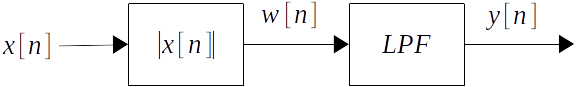

where $w[n] = |x[n]|$ and $y[n]$ was the output of a low-pass FIR filter (averaging filter). In this exercise, you will re-implement this low-pass filter as an IIR.

1.1 First, copy the functions envelope and synthesize from previous work and obtain the same synthesis. 



In [8]:
# Write your code here
import numpy as np
def envelope(x, N):
    """Extracts the envelope of the input signal x

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e the envelope of the signal x.
    """
    rectified = np.abs(x)
    h = np.ones(N) / N
    y = np.convolve(rectified, h, mode='same')

    return y


from IPython.display import Audio
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y
weights = [0.01, 1,0.14,0.84,0.26,0.69,0.66,0.01,0.2,0.07,0.1,0.03,0.01,0.1,0.02,0.01] 
filepath = "guitarra.wav"
ref, fs = load_audio(filepath)
f0 = 80.74951  
period = 1 / f0
three_periods = 3 * period
t_start = 0.1
t_end = t_start + three_periods
amplitude_reference_signal = 0.3
phi = np.pi / 2 
amplitudes_raw = [80.75, 161.50, 247.63, 328.38, 409.13, 489.88, 576.01, 656.76, 742.89, 823.64, 
                  904.39, 985.14, 1071.27, 1152.02, 1238.15]
amplitudes_harmonics_relative = [amp / f0 for amp in amplitudes_raw]
y = 0
y_normalized = amplitude_reference_signal * y / np.max(np.abs(y))


C:\Users\Paula\AppData\Local\Temp\ipykernel_20680\689573548.py:45: RuntimeWarning:

invalid value encountered in divide



1.2 Let's take a look at the following system:

$$
H(z) = G\frac{1+z^{-1}}{1-rz^{-1}} \quad   0<r<1 \quad, G = \frac{1-r}{2}
$$

Note that the coefficients of the filter are the following:

$$
b_0 = 1, \quad b_1 = 1, \quad a_0 = 1, \quad a_1 = -r, \quad
$$

i. Find the zeros and poles of the system analytically.

we obtain that:

H(z) = (1-z) + z^-1 (1 - r) / 2- 2rz^-1

- Zeros => numerator = 0 => z = -1
- Poles => denominator = 0 => z = r

ii. Use the function `np.roots` to find the zeros and poles using Python. Compare the results with part i.

In [9]:
# Write your code here
r=0.9
poles=0
zeros=0

coef_zeros= [1, 1]
coef_poles = [1, -r]
zeros = zeros + np.roots(coef_zeros)
poles = poles + np.roots(coef_poles)

print(zeros)
print(poles)

[-1.]
[0.9]


iii. Use the function  `plot_zeros_poles(z, p)` to plot the zeros and poles found in ii.

In [11]:
from util import plot_zeros_poles
plot_zeros_poles(zeros,poles)
# Write your code here

1.3 Let's see the frequency response of this filter:



In [ ]:
# Write your code here

1.4. Change the parameter $r$ in the range $(0, 1)$. What happens when $r$ is increased?

When r is increased, the zeros and the poles change. But when they are plotted, as they must fit in the unit circle, the representation remains the same. 
When we are computing the magnitude and phase, if we increment r, the values will be slightly higher than if we have a smaller r

1.5 What type of filter is (low-pass, band-pass, or high-pass filter)?


[Double click to write your answer]

1.6 Now we can use this IIR filter to extract the envelope. Let's define a new function `envelope_iir(x)` that applies the filter to the absolute value of the signal. Note that we are using signal.lfilter function to apply the filter.


In [ ]:
def envelope_iir(x, r=0.995):
    rectified= np.abs(x) #take the absolute value of the signal
    a = [1,-r] #a coefficients (given by the exercise previously)
    g= (1-r)/2
    b = [g,g] # b coefficients (given by the exercise previously)
   
    iir_filter = signal.lfilter(b,a,rectified) # implements difference equation for iir filters and returns the filtered output
    return iir_filter #return the result

Extract the envelope of your reference signal using both the FIR and IIR filters and compare the results plot them along with the signal. Change the value of $r$ until you are comfortable with the result.

In [ ]:
env_fir= envelope(ref, 500)
env_iir = envelope_iir(ref, r=0.999)
plot_signals([np.abs(ref), env_fir, env_iir], fs, t_start=0, t_end=1.0, name=["original", "fir", "iir"] )

1.7 What are the main differences between the two filters? For instance, compare the number of coefficients.

[Double click to write your answer]

1.8 Apply the new envelope (extracted from the IIR filter) to the synthesis generated with the `synthesize` function and listen to the result.

In [ ]:
# Write your code 
t_full = np.linspace(0, len(ref)/fs, len(ref))
y= synthesize(80.74951, 0, weights, t_full)
y= y*env_iir
y= np.amax(ref)*y/np.amax(y)
plot_signals([ref,y], fs, t_start=0, t_end=1.5, name=['original', 'synthesized'])
display(Audio(y, rate=fs))

---

**2. Band-pass filters**

Now let's work with the following system: 

$$
H(z) = \frac{(1-z^{-1})(1+z^{-1})}{(1-re^{j\omega_n}z^{-1})(1-re^{-j\omega_n}z^{-1})}, \quad 0<r<1
$$

Note that the poles are $p_1 = re^{j\omega_n}$ and $p_2 = re^{-j\omega_n}$; and the zeros are $z_1=1$ and $z_2=-1$. 

2.1 Use the function `plot_zeros_poles` to plot the zeros and poles of the system.

Note: use $w_n = \pi/4$ and $r=0.99$.

In [ ]:
# Write your code here

2.2 Show analytically that $a_k = [1, -2rcos(\omega_n), r^2]$ and $b_k=[1, 0, -1]$.

[Double click to write your answer]

2.3 Plot the frequency response of the filter. Confirm this is a band-pass filter. What's the central frequency of the passband?

In [ ]:
# Write your code here

[Double click to write your answer]


2.4 Define a function `bpf(x, f, r, fs)` that applies the above band-pass filter. 

Note 1: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$.

Note 2: use `signal.lfilter` function to implement the filter.

In [ ]:
import numpy as np
from scipy import signal

def bpf(x, fn, fs, r=0.995):
    """
    Applies a band-pass filter with central frequency fn.

    Parameters
    ----------
    x : np.array
        Input signal
    fn : float
        Central frequency of the band-pass in Hz
    fs : float
        Sampling frequency in Hz
    r : float, optional
        Pole radius (default 0.995)

    Returns
    -------
    y : np.array
        Filtered output signal
    """
    omega_n = 2 * np.pi * fn / fs
    b = np.array([1, 0, -1])                       
    a = np.array([1, -2*r*np.cos(omega_n), r**2])  
    y = signal.lfilter(b, a, x)

    return y

2.5 Regardless of the phase, until now we were synthesizing the instrument signal by summing $K$ harmonics of the signal with different weights ($A_k$) and multiplying the sum by the envelope of the reference signal ($e(t)$):

$$y(t) = e(t) \cdot \sum_{k=1}^K A_k\cos\left(2\pi kf_0 t \right), $$

where $f_0$ is the fundamental frequency of the note. Now we want to improve this synthesis by finding a time-dependent amplitude ($A_k(t)$) for each harmonic:

$$y(t) = \sum_{k=1}^K A_k(t) \cos\left(2\pi kf_0 t \right), $$

where $A_k(t)$ is the amplitude of the harmonic $k$. To extract the amplitudes $A_k(t)$ we'll apply a band-pass filter with central frequency $kf_0$ and calculate the envelope of the output by using the `envelope_iir`.


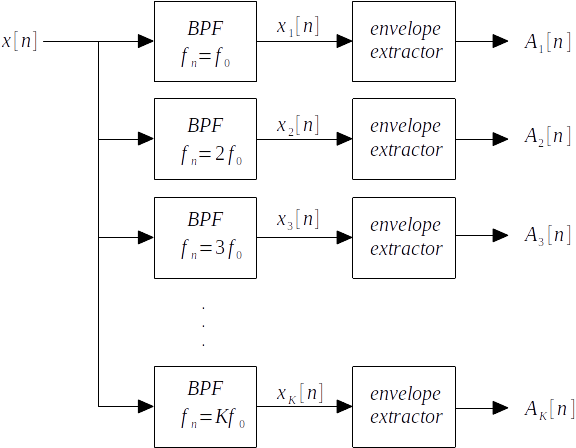

For instance, the following code should extract the envelope of the fundamental frequency component. Change the value of $f_0$ to coincide with your fundamental frequency and check the result. 

In [ ]:
# Write your code here
# Write your code here
f0= 80.74951
x_1 = bpf(ref, f0, fs)
a1= envelope_iir(x_1, r=0.999)
plot_signals([x_1, a1], fs, t_start=0, t_end=1.5,name=["x_0(t)", 'e_0(t)'])

2.6 Complete the `synthetize_with_bpf` function to implement a synthesis applying different envelopes for each harmonic.


In [ ]:
def synthetize_with_bpf(x, f0, phi, K, fs):
  """Synthetizes an harmonic signal using different envelopes for each harmonic
  The envelops are extracted from the reference signal x.

  Parameters
  ----------
  x : np.array
      The reference signal in the form of a numpy array
   f0: int or float
      Fundamental frequency of the synthesis
  phi : float
      Phase
  K: int
      Number of harmonics
  fs : int or float
      Frequency rate in Hz

  Returns
  -------
  y : np.array
      The output of the filter

  """
  # Write your code here
  Ts=1/float(fs)
  t=np.arange(0,len(ref)*Ts,Ts)

  y=0

  for k in range(1,int(K)+1):
    x_k=bpf(x,f0*k,fs)
    x_k=bpf(x_k,f0*k,fs)
    x_k=bpf(x_k,f0*k,fs)
    A_k=envelope_iir(x_k,0.999)
    y+=A_k*np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  y=np.amax(x)*y/np.amax(y)
  return y
  # Write your code here

2.6 Call the function `synthetize_with_bpf` to get the synthesized signal and **listen to it**.

Note that now you can increase the number of harmonics $K$ as you want because we are not manually measuring the weights of each harmonic.

In [ ]:
# Write your code here
f0= 80.74951
phi=0
k=20
y= synthetize_with_bpf(ref, f0, phi, k, fs)
display(Audio(y, rate=fs))
display(Audio(ref, rate=fs))

2.7 Compare the **spectrograms** of the synthesized signal and reference signal.

In [ ]:
# Write your code here